# v3 key results — parameter scatter, surrogate reconstruction, SV ablation

Condensed eval notebook for `exp-v3_encoder-lipschitz_dann_flow-maf5`.

**Sections:** real-patient parameter scatter vs GT · surrogate reconstruction (mmHg) · SV ablation (v3 vs v3_nosv, direct vs 1NN).

In [50]:
import json, sys, h5py, csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

try:
    ROOT = Path(globals()['_dh'][0]).parent
    assert (ROOT / 'dataset.py').exists()
except:
    ROOT = Path('/home/sa4604/cv-dann-sbi')
sys.path.insert(0, str(ROOT))

from dataset import (
    load_stats, load_manifest, ReducedCVDataset,
    PARAM_KEYS_INFER, N_CHANNELS, T, WAVE_KEYS_CONT,
)
from models import LipschitzReducedAutoencoderEncoder

WAVE_KEYS_REAL = ['Prv', 'Pra', 'Pvp', 'Pap']

device = torch.device('cuda:0')
print('device:', device)

device: cuda:0


In [51]:
RUN        = 'exp-v3_encoder-lipschitz_dann_flow-maf5'
VERSION    = '3'
RUN_DIR    = ROOT / f'outputs/{RUN}'

REAL_DATA  = Path('/home/sa4604/real_data/onebeat_300patients')
SIM_ROOT   = Path('/media/local/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314')
STATS_PATH = ROOT / 'norm_stats.json'

N_POSTERIOR_SAMPLES = 1000
N_SIM_PCA           = 500

stats    = load_stats(STATS_PATH)
manifest = load_manifest(SIM_ROOT / 'manifest_train.json')
lo_t = torch.tensor([manifest['config']['pvar_low'][k]  for k in PARAM_KEYS_INFER], dtype=torch.float32)
hi_t = torch.tensor([manifest['config']['pvar_high'][k] for k in PARAM_KEYS_INFER], dtype=torch.float32)
print('Prior bounds loaded for', len(PARAM_KEYS_INFER), 'parameters')

Prior bounds loaded for 24 parameters


## Load models

In [53]:
encoder = LipschitzReducedAutoencoderEncoder(latent_dim=128).to(device)
encoder.load_state_dict(torch.load(RUN_DIR / 'encoder.pt', map_location=device))
encoder.eval()
print('Encoder loaded:', encoder.describe())

flow_net = torch.load(RUN_DIR / 'flow_net.pt', map_location=device, weights_only=False)
flow_net.eval()
print('Flow loaded:', type(flow_net).__name__)

Encoder loaded: {'type': 'LipschitzReducedAutoencoderEncoder', 'input_waveforms': '(4, 201)', 'input_scalars': 'Pas_mean, Pas_max, Pas_min, SV, HR_z', 'latent_dim': 128, 'proj_hidden': None, 'sn_ceiling': 2.0, 'n_params': 439617}
Flow loaded: NFlowsFlow


## Load real patients

In [54]:
w = stats['waves']
p = stats['parameters']
wave_mean = torch.tensor([w[k]['mean'] for k in WAVE_KEYS_REAL], dtype=torch.float32).unsqueeze(1)
wave_std  = torch.tensor([w[k]['std']  for k in WAVE_KEYS_REAL], dtype=torch.float32).unsqueeze(1)
pas_mean, pas_std = w['Pas']['mean'], w['Pas']['std'] + 1e-8
vlv_std           = w['Vlv']['std'] + 1e-8
hr_mean,  hr_std  = p['HR']['mean'],  p['HR']['std']  + 1e-8

patients = []
for fpath in sorted(REAL_DATA.glob('*.h5')):
    beats_x, gt = [], {}
    with h5py.File(fpath, 'r') as f:
        for bk in sorted(f.keys()):
            if not bk.startswith('beat_'): continue
            g = f[bk]
            waves = np.stack([g[f'waves/{k}'][:].astype(np.float32) for k in WAVE_KEYS_REAL])
            wt    = (torch.from_numpy(waves) - wave_mean) / (wave_std + 1e-8)
            sbp   = float(g['summaries/sbp'][()])
            dbp   = float(g['summaries/dbp'][()])
            map_  = float(g['summaries/map'][()])
            sv    = float(g['summaries/sv'][()])
            hr    = float(g['parameters/HR'][()])
            sc = torch.tensor([
                (map_ - pas_mean) / pas_std,
                (sbp  - pas_mean) / pas_std,
                (dbp  - pas_mean) / pas_std,
                sv    / vlv_std,
                (hr   - hr_mean)  / hr_std,
            ], dtype=torch.float32)
            beats_x.append(torch.cat([wt.reshape(-1), sc]))
            if not gt:
                gt = {k: float(g[f'parameters/{k}'][()]) for k in f[bk]['parameters'].keys()}
                # summaries
                for sk in g['summaries'].keys():
                    gt[sk] = float(g[f'summaries/{sk}'][()])
                # covariates (cohort label, id)
                cov = g['covariates']
                gt['cohort'] = cov['cohort'][()].decode() if isinstance(cov['cohort'][()], bytes) else str(cov['cohort'][()])
                gt['id']     = cov['id'][()].decode()     if isinstance(cov['id'][()],     bytes) else str(cov['id'][()])
    if beats_x:
        x_beats = torch.stack(beats_x)
        patients.append(dict(file=fpath.stem, x_beats=x_beats, x_avg=x_beats.mean(0), gt=gt))

cohort_counts = {}
for pat in patients:
    c = pat['gt'].get('cohort', 'unknown')
    cohort_counts[c] = cohort_counts.get(c, 0) + 1
print(f'Loaded {len(patients)} patients, {sum(len(p["x_beats"]) for p in patients)} total beats')
print(f'Cohorts: {cohort_counts}')

Loaded 802 patients, 802 total beats
Cohorts: {'controls': 173, 'pah': 629}


In [57]:
cas_idx = PARAM_KEYS_INFER.index('Cas')
eap_idx = PARAM_KEYS_INFER.index('Eap')
rap_idx = PARAM_KEYS_INFER.index('Rap')
ras_idx = PARAM_KEYS_INFER.index('Ras')

import time
print(f'Direct inference on {len(patients)} real patients (N={N_POSTERIOR_SAMPLES} samples each)...')

cas_d, eap_d, rap_d, ras_d, accept_rates, theta_means = [], [], [], [], [], []
rap_samples_all = []   # full posteriors for calibration
ras_samples_all = []
t0 = time.time()

for pi, pat in enumerate(patients):
    x = pat['x_avg'].unsqueeze(0).to(device)
    with torch.no_grad():
        z       = encoder(x)                                              # (1, latent_dim)
        samples = flow_net.sample((N_POSTERIOR_SAMPLES,), condition=z)   # (N, 1, 24)
        samples = samples.squeeze(1).cpu()                                # (N, 24)
    in_prior = ((samples >= lo_t) & (samples <= hi_t)).all(dim=1)
    accept   = in_prior.float().mean().item()
    accept_rates.append(accept)
    s_ok  = samples[in_prior] if in_prior.any() else samples
    means = s_ok.mean(0).numpy()
    theta_means.append(means)
    cas_d.append(means[cas_idx]); eap_d.append(means[eap_idx])
    rap_d.append(means[rap_idx]); ras_d.append(means[ras_idx])
    rap_samples_all.append(samples[:, rap_idx].numpy())
    ras_samples_all.append(samples[:, ras_idx].numpy())
    if pi % 100 == 0 or pi < 3:
        print(f'  [{pi:3d}] accept={accept:.3f}  '
              f'Cas={cas_d[-1]:.3f} (GT={pat["gt"].get("Cas", float("nan")):.3f})  '
              f'({time.time()-t0:.0f}s)')

cas_d = np.array(cas_d); eap_d = np.array(eap_d)
rap_d = np.array(rap_d); ras_d = np.array(ras_d)
accept_rates    = np.array(accept_rates)
theta_means     = np.stack(theta_means)
rap_samples_all = np.stack(rap_samples_all)  # (802, N_posterior)
ras_samples_all = np.stack(ras_samples_all)
print(f'\nMean acceptance: {accept_rates.mean():.3f}  '
      f'({(accept_rates > 0).sum()}/{len(patients)} patients with nonzero acceptance)')

Direct inference on 802 real patients (N=1000 samples each)...
  [  0] accept=0.048  Cas=0.947 (GT=1.230)  (0s)
  [  1] accept=0.021  Cas=0.890 (GT=1.190)  (0s)
  [  2] accept=0.002  Cas=0.904 (GT=1.190)  (0s)
  [100] accept=0.310  Cas=1.233 (GT=1.730)  (6s)
  [200] accept=0.000  Cas=0.634 (GT=0.910)  (11s)
  [300] accept=0.199  Cas=0.649 (GT=0.847)  (16s)
  [400] accept=0.000  Cas=0.370 (GT=0.540)  (20s)
  [500] accept=0.218  Cas=0.693 (GT=0.987)  (24s)
  [600] accept=0.212  Cas=0.894 (GT=1.320)  (28s)
  [700] accept=0.000  Cas=1.069 (GT=1.310)  (32s)
  [800] accept=0.010  Cas=0.609 (GT=0.854)  (36s)

Mean acceptance: 0.050  (322/802 patients with nonzero acceptance)


## Parameter scatter — posterior mean vs GT

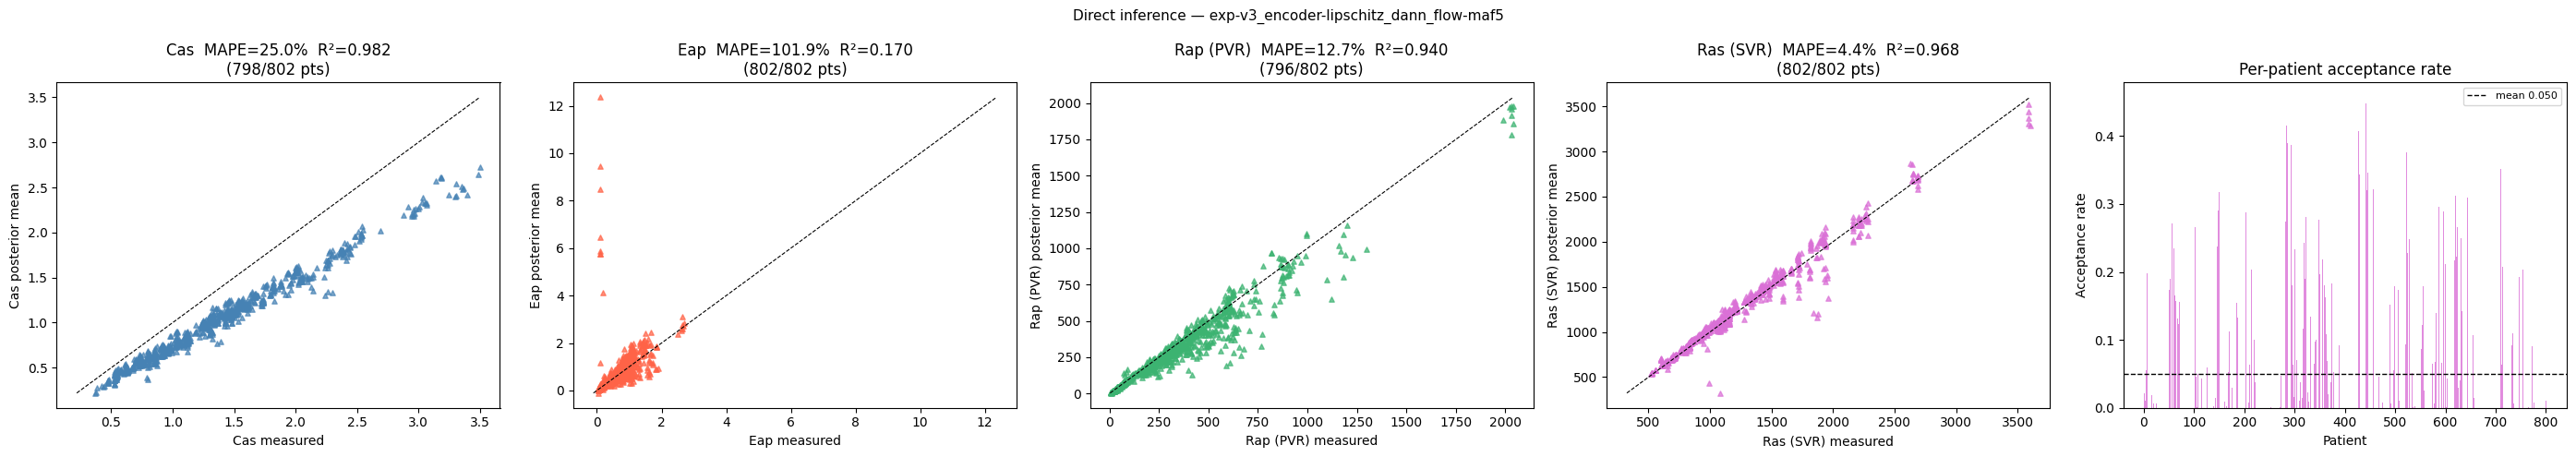


Parameter        MAPE      R²
------------------------------
Cas             25.0%   0.982
Eap            101.9%   0.170
Rap(PVR)        12.7%   0.940
Ras(SVR)         4.4%   0.968


In [58]:
from scipy.stats import pearsonr

cas_gt = np.array([pat['gt'].get('Cas', np.nan) for pat in patients])
eap_gt = np.array([pat['gt'].get('Eap', np.nan) for pat in patients])
rap_gt = np.array([pat['gt'].get('PVR', np.nan) for pat in patients])
ras_gt = np.array([pat['gt'].get('SVR', np.nan) for pat in patients])

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
for ax, pred, gt, name, color in [
    (axes[0], cas_d, cas_gt, 'Cas',       'steelblue'),
    (axes[1], eap_d, eap_gt, 'Eap',       'tomato'),
    (axes[2], rap_d, rap_gt, 'Rap (PVR)', 'mediumseagreen'),
    (axes[3], ras_d, ras_gt, 'Ras (SVR)', 'orchid'),
]:
    valid = ~np.isnan(pred) & ~np.isnan(gt) & (gt >= 0)
    if valid.any():
        lo = np.nanmin([gt[valid].min(), pred[valid].min()])
        hi = np.nanmax([gt[valid].max(), pred[valid].max()])
        ax.scatter(gt[valid], pred[valid], s=15, alpha=0.7, color=color, marker='^')
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
        mape = np.nanmean(np.abs(pred[valid] - gt[valid]) / (np.abs(gt[valid]) + 1e-9)) * 100
        r2   = pearsonr(gt[valid], pred[valid])[0] ** 2
        ax.set_title(f'{name}  MAPE={mape:.1f}%  R²={r2:.3f}\n({valid.sum()}/{len(patients)} pts)')
    else:
        ax.set_title(f'{name}  0 valid')
    ax.set_xlabel(f'{name} measured'); ax.set_ylabel(f'{name} posterior mean')

ax = axes[4]
ax.bar(range(len(patients)), accept_rates, color='orchid', alpha=0.8)
ax.axhline(accept_rates.mean(), color='black', linestyle='--', linewidth=1,
           label=f'mean {accept_rates.mean():.3f}')
ax.set_xlabel('Patient'); ax.set_ylabel('Acceptance rate')
ax.set_title('Per-patient acceptance rate'); ax.legend(fontsize=8)

fig.suptitle(f'Direct inference — {RUN}', fontsize=11)
plt.tight_layout(); plt.show()

print(f'\n{"Parameter":<12} {"MAPE":>8} {"R²":>7}')
print('-' * 30)
for pred, gt, name in [
    (cas_d, cas_gt, 'Cas'), (eap_d, eap_gt, 'Eap'),
    (rap_d, rap_gt, 'Rap(PVR)'), (ras_d, ras_gt, 'Ras(SVR)'),
]:
    valid = ~np.isnan(pred) & ~np.isnan(gt) & (gt >= 0)
    if valid.sum() > 1:
        mape = np.nanmean(np.abs(pred[valid] - gt[valid]) / (np.abs(gt[valid]) + 1e-9)) * 100
        r2   = pearsonr(gt[valid], pred[valid])[0] ** 2
        print(f'{name:<12} {mape:>7.1f}%  {r2:>6.3f}')

## Surrogate reconstruction — physical units (mmHg)

Posterior mean theta → surrogate decoder → predicted waveforms vs real observed channels (Prv, Pra, Pvp, Pap).

- **Plot 1** — posterior mean theta: 8 example patients × 4 channels
- **Plot 2** — P5–P95 envelope from T=1 posterior samples, 8 example patients
- **Table** — per-channel RMSE (mmHg) and Pearson r over all 802 patients

In [ ]:
import importlib.util as _ilu, time

_spec = _ilu.spec_from_file_location("sbi_sim_models", "/home/sa4604/cv-sbi-sim/models.py")
_sbi_sim_models = _ilu.module_from_spec(_spec)
_spec.loader.exec_module(_sbi_sim_models)
SurrogateDecoder = _sbi_sim_models.SurrogateDecoder

SURROGATE_DIR  = Path('/home/sa4604/cv-sbi-sim/outputs/exp-v1_mlp-surrogate_sims')
N_SURR_SAMPLES = 200
N_EXAMPLES     = 8
N_T            = 201
t_axis         = np.arange(N_T)

decoder = SurrogateDecoder().to(device)
decoder.load_state_dict(
    torch.load(SURROGATE_DIR / 'decoder.pt', map_location=device, weights_only=True))
decoder.eval()

tn      = json.load(open(SURROGATE_DIR / 'theta_norm.json'))
tn_keys = tn['keys']
tn_mean = torch.tensor(tn['mean'], dtype=torch.float32, device=device)
tn_std  = torch.tensor(tn['std'],  dtype=torch.float32, device=device)

COMPARE_IDXS = [list(WAVE_KEYS_CONT).index(k) for k in WAVE_KEYS_REAL]

def build_theta25(theta_24_np, hr):
    t25 = np.empty(25, dtype=np.float32)
    for i, k in enumerate(tn_keys):
        t25[i] = float(hr) if k == 'HR' else theta_24_np[PARAM_KEYS_INFER.index(k)]
    return t25

def decode_batch(theta25_batch_np):
    """(N, 25) physical theta → (N, 4, N_T) z-scored waveforms for WAVE_KEYS_REAL."""
    t = torch.from_numpy(theta25_batch_np).to(device)
    t = (t - tn_mean) / (tn_std + 1e-8)
    with torch.no_grad():
        out = decoder(t)
    out_np = out.cpu().numpy().reshape(len(theta25_batch_np), 24, N_T)
    return out_np[:, COMPARE_IDXS, :]

# ── De-normalise helpers ──────────────────────────────────────────────────────
wave_mean_arr = np.array([stats['waves'][k]['mean'] for k in WAVE_KEYS_REAL], dtype=np.float32)
wave_std_arr  = np.array([stats['waves'][k]['std']  for k in WAVE_KEYS_REAL], dtype=np.float32)

def to_mmhg(z):
    """(N, 4, T) z-scored → mmHg."""
    return z * wave_std_arr[None, :, None] + wave_mean_arr[None, :, None]

# ── Build arrays ──────────────────────────────────────────────────────────────
real_waves_all = np.stack([
    pat['x_avg'][:len(WAVE_KEYS_REAL) * N_T].numpy().reshape(len(WAVE_KEYS_REAL), N_T)
    for pat in patients
])  # (802, 4, 201) z-scored

hr_all      = np.array([float(pat['gt'].get('HR', np.nan)) for pat in patients])
theta25_all = np.stack([build_theta25(theta_means[pi], hr_all[pi]) for pi in range(len(patients))])
recon_mean  = decode_batch(theta25_all)  # (802, 4, 201) z-scored

real_phys  = to_mmhg(real_waves_all)
recon_phys = to_mmhg(recon_mean)

example_idxs   = [i * (len(patients) // N_EXAMPLES) for i in range(N_EXAMPLES)]
example_labels = [f'Pat {pi}  ({patients[pi]["gt"].get("cohort","?")})' for pi in example_idxs]

print('Surrogate loaded. real_phys:', real_phys.shape, '  recon_phys:', recon_phys.shape)

# ── Plot 1: posterior mean reconstruction — 8 examples ───────────────────────
fig, axes = plt.subplots(len(WAVE_KEYS_REAL), N_EXAMPLES,
                         figsize=(4 * N_EXAMPLES, 3 * len(WAVE_KEYS_REAL)), sharey='row')
for ci, ch in enumerate(WAVE_KEYS_REAL):
    for ei, pi in enumerate(example_idxs):
        ax = axes[ci, ei]
        ax.plot(t_axis, real_phys[pi, ci],  color='black',  lw=1.2, label='real')
        ax.plot(t_axis, recon_phys[pi, ci], color='tomato', lw=1.2, ls='--', label='mean recon')
        if ci == 0:                          ax.set_title(example_labels[ei], fontsize=8)
        if ei == 0:                          ax.set_ylabel(f'{ch} (mmHg)', fontsize=9)
        if ci == len(WAVE_KEYS_REAL) - 1:   ax.set_xlabel('time step', fontsize=7)
        if ci == 0 and ei == N_EXAMPLES - 1: ax.legend(fontsize=7)
fig.suptitle(f'Surrogate reconstruction — posterior mean — {RUN}', fontsize=11)
plt.tight_layout(); plt.show()

# ── T=1 envelope — 8 examples in mmHg ────────────────────────────────────────
lo_np = lo_t.numpy(); hi_np = hi_t.numpy()

def sample_and_decode_phys(ex_idxs, T_temp):
    """Returns (N_ex, N_surr, 4, N_T) in mmHg."""
    all_recons = []
    for pi in ex_idxs:
        x = patients[pi]['x_avg'].unsqueeze(0).to(device)
        with torch.no_grad():
            z_pt  = encoder(x)
            s_raw = flow_net.sample((N_SURR_SAMPLES,), condition=z_pt).squeeze(1).cpu().numpy()
        mean_s = s_raw.mean(axis=0, keepdims=True)
        s_T    = np.clip(mean_s + T_temp * (s_raw - mean_s), lo_np, hi_np)
        hr     = float(patients[pi]['gt'].get('HR', hr_all[pi]))
        t25b   = np.stack([build_theta25(s_T[n], hr) for n in range(N_SURR_SAMPLES)])
        recon_z = decode_batch(t25b)  # (N_surr, 4, N_T) z-scored
        all_recons.append(to_mmhg(recon_z))
    return np.stack(all_recons)  # (N_ex, N_surr, 4, N_T) mmHg

print(f'Sampling T=1 envelope ({N_SURR_SAMPLES} samples × {N_EXAMPLES} patients)...')
env_T1_phys = sample_and_decode_phys(example_idxs, T_temp=1.0)

fig, axes = plt.subplots(len(WAVE_KEYS_REAL), N_EXAMPLES,
                         figsize=(4 * N_EXAMPLES, 3 * len(WAVE_KEYS_REAL)), sharey='row')
for ci, ch in enumerate(WAVE_KEYS_REAL):
    for ei, pi in enumerate(example_idxs):
        ax = axes[ci, ei]
        e  = env_T1_phys[ei, :, ci, :]
        ax.fill_between(t_axis, np.percentile(e, 5, axis=0), np.percentile(e, 95, axis=0),
                        alpha=0.25, color='tomato', label='P5–P95')
        ax.plot(t_axis, e.mean(axis=0),        color='tomato', lw=1.0, ls='--', label='mean recon')
        ax.plot(t_axis, real_phys[pi, ci],     color='black',  lw=1.2,          label='real')
        if ci == 0:                          ax.set_title(example_labels[ei], fontsize=8)
        if ei == 0:                          ax.set_ylabel(f'{ch} (mmHg)', fontsize=9)
        if ci == len(WAVE_KEYS_REAL) - 1:   ax.set_xlabel('time step', fontsize=7)
        if ci == 0 and ei == N_EXAMPLES - 1: ax.legend(fontsize=7)
fig.suptitle(f'Surrogate reconstruction — T=1 envelope (P5–P95, {N_SURR_SAMPLES} samples) — {RUN}', fontsize=11)
plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
err_phys     = recon_phys - real_phys
mse_phys_ch  = (err_phys ** 2).mean(axis=(0, 2))
rmse_phys_ch = np.sqrt(mse_phys_ch)

corr_ch = np.zeros((len(patients), len(WAVE_KEYS_REAL)))
for ci in range(len(WAVE_KEYS_REAL)):
    for pi in range(len(patients)):
        r = np.corrcoef(recon_phys[pi, ci], real_phys[pi, ci])[0, 1]
        corr_ch[pi, ci] = r if np.isfinite(r) else 0.0
corr_mean_ch = corr_ch.mean(axis=0)

print(f'\nSurrogate reconstruction — posterior mean — all {len(patients)} patients')
print(f'{"Channel":<8} {"MSE (mmHg²)":>13} {"RMSE (mmHg)":>13} {"Pearson r":>10}')
print('-' * 48)
for ci, ch in enumerate(WAVE_KEYS_REAL):
    print(f'{ch:<8} {mse_phys_ch[ci]:>13.2f} {rmse_phys_ch[ci]:>13.3f} {corr_mean_ch[ci]:>10.4f}')
print('-' * 48)
print(f'{"mean":<8} {mse_phys_ch.mean():>13.2f} {rmse_phys_ch.mean():>13.3f} {corr_mean_ch.mean():>10.4f}')


In [ ]:
import time

N_SIM_EVAL = 1000

manifest_test = load_manifest(SIM_ROOT / 'manifest_test.json')
ds_test = ReducedCVDataset(str(SIM_ROOT / 'test'), manifest_test['index'][:N_SIM_EVAL], stats)
theta_test, x_test = zip(*[ds_test[i] for i in range(len(ds_test))])
theta_test = torch.stack(list(theta_test))  # (N, 24)
x_test     = torch.stack(list(x_test))      # (N, 809)
print(f'Test sims: {tuple(theta_test.shape)}  obs: {tuple(x_test.shape)}')


---
## SV ablation: v3 (with SV) vs v3_nosv (no SV) on real patients

Tests whether removing the SV scalar from the observation hurts SV recovery.
SV is derived via the S1 surrogate using **Vrv** (right ventricular volume) — matching
thermodilution GT which measures right-heart cardiac output.

In [73]:
import importlib.util, time

ROOT_SIM = Path('/home/sa4604/cv-sbi-sim')
OUT_V3_NOSV = ROOT / 'outputs/exp-v3_nosv_encoder-lipschitz_dann_flow-maf5'
OUT_S1      = ROOT_SIM / 'outputs/exp-v1_mlp-surrogate_sims'

# Load v3_nosv encoder + flow
enc_nosv = LipschitzReducedAutoencoderEncoder(latent_dim=128, n_scalars=4).to(device)
enc_nosv.load_state_dict(torch.load(OUT_V3_NOSV / 'encoder.pt', map_location=device))
enc_nosv.eval()
flow_nosv = torch.load(OUT_V3_NOSV / 'flow_net.pt', map_location=device, weights_only=False)
flow_nosv.eval()
print('v3_nosv encoder:', enc_nosv.describe())

# Load S1 surrogate from cv-sbi-sim
_spec = importlib.util.spec_from_file_location('sim_models', ROOT_SIM / 'models.py')
_sim  = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_sim)
SurrogateDecoder = _sim.SurrogateDecoder

with open(OUT_S1 / 'theta_norm.json') as _f:
    _tn = json.load(_f)
theta_norm_mean = torch.tensor(_tn['mean'], dtype=torch.float32).to(device)
theta_norm_std  = torch.tensor(_tn['std'],  dtype=torch.float32).to(device)

surrogate = SurrogateDecoder(hidden=512, n_layers=4).to(device)
surrogate.load_state_dict(torch.load(OUT_S1 / 'decoder.pt', map_location=device))
surrogate.eval()

vrv_idx = WAVE_KEYS_CONT.index('Vrv')
vrv_std = stats['waves']['Vrv']['std']
vlv_idx = WAVE_KEYS_CONT.index('Vlv')
vlv_std = stats['waves']['Vlv']['std']
HR_IDX  = 17  # position of HR in 25-param PARAM_KEYS
N_CONT  = len(WAVE_KEYS_CONT)  # 24

# Build 808-dim beats for v3_nosv (drop SV scalar at position 807)
# Observation layout: [wave(804), map(1), sbp(1), dbp(1), sv(1), hr(1)] = 809
# Drop sv => [wave(804), map(1), sbp(1), dbp(1), hr(1)] = 808
for pat in patients:
    x809 = pat['x_beats']          # (n_beats, 809)
    pat['x_beats_nosv'] = torch.cat([x809[:, :807], x809[:, 808:]], dim=1)   # (n_beats, 808)
    pat['x_avg_nosv']   = pat['x_beats_nosv'].mean(0)

print(f'v3_nosv obs dim: {patients[0]["x_avg_nosv"].shape[0]}')
print(f'Surrogate loaded. vrv_idx={vrv_idx}, vrv_std={vrv_std:.2f}')

v3_nosv encoder: {'type': 'LipschitzReducedAutoencoderEncoder', 'input_waveforms': '(4, 201)', 'input_scalars': 'Pas_mean, Pas_max, Pas_min, HR_z', 'latent_dim': 128, 'proj_hidden': None, 'sn_ceiling': 2.0, 'n_params': 439105}
v3_nosv obs dim: 808
Surrogate loaded. vrv_idx=21, vrv_std=35.26


In [74]:
# Run posterior inference for v3 and v3_nosv on all real patients
N_ABL = N_POSTERIOR_SAMPLES

def run_ablation_inference(enc, flow, x_key):
    samps, hrs = [], []
    t0 = time.time()
    for pi, pat in enumerate(patients):
        x = pat[x_key].unsqueeze(0).to(device)
        with torch.no_grad():
            z = enc(x)
            s = flow.sample((N_ABL,), condition=z).squeeze(1).cpu()  # (N_ABL, 24)
        samps.append(s.numpy())
        hrs.append(pat['gt']['HR'])
        if pi % 100 == 0:
            print(f'  {pi}/{len(patients)}  ({time.time()-t0:.0f}s)', end='\r', flush=True)
    print(f'  done ({time.time()-t0:.0f}s)')
    return np.stack(samps), np.array(hrs)  # (N_pat, N_ABL, 24), (N_pat,)

print('Running v3 (with SV)...')
samp_v3,     hr_arr = run_ablation_inference(encoder,   flow_net,   'x_avg')
print('Running v3_nosv (no SV)...')
samp_v3_nosv, _     = run_ablation_inference(enc_nosv,  flow_nosv,  'x_avg_nosv')

sv_gt = np.array([pat['gt']['sv'] for pat in patients])
print(f'\nsamples: {samp_v3.shape}  GT SV: {sv_gt.min():.0f}–{sv_gt.max():.0f} mL')

Running v3 (with SV)...
  done (36s)36s)
Running v3_nosv (no SV)...
  done (34s)34s)

samples: (802, 1000, 24)  GT SV: 23–160 mL


Deriving RVSV via Vrv (v3)...
Deriving RVSV via Vrv (v3_nosv)...
Deriving LVSV via Vlv (v3)...
Deriving LVSV via Vlv (v3_nosv)...


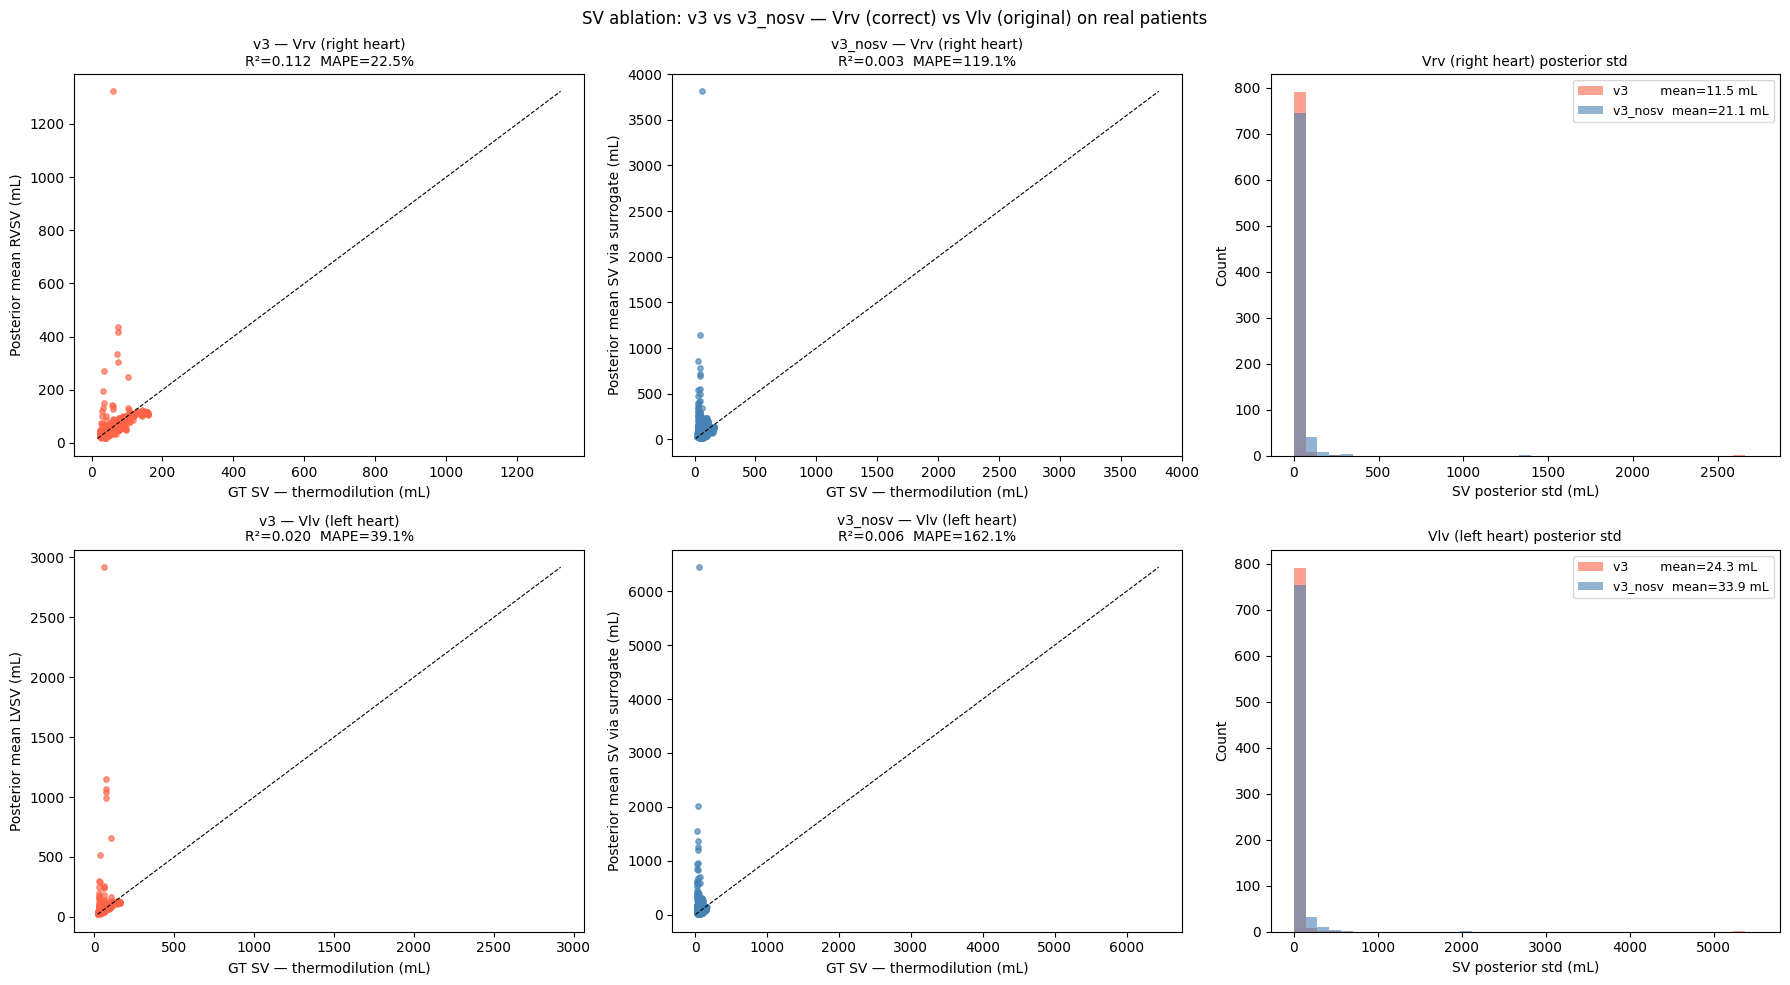

v3 — Vrv (right heart)                    R²=0.112  MAPE=22.5%  post_std=11.5 mL
v3_nosv — Vrv (right heart)               R²=0.003  MAPE=119.1%  post_std=21.1 mL
v3 — Vlv (left heart)                     R²=0.020  MAPE=39.1%  post_std=24.3 mL
v3_nosv — Vlv (left heart)                R²=0.006  MAPE=162.1%  post_std=33.9 mL


In [75]:
# Derive SV via S1 surrogate using either Vrv (right heart) or Vlv (left heart)
def derive_sv(samples_24, hr_arr, wave_idx, wave_std_val):
    """samples_24: (N_pat, N_ABL, 24); returns SV (N_pat, N_ABL) in mL."""
    N_pat = len(samples_24)
    sv_out = np.zeros((N_pat, N_ABL))
    for i in range(N_pat):
        s24 = torch.from_numpy(samples_24[i]).float()
        hr_col = torch.full((N_ABL, 1), float(hr_arr[i]))
        s25 = torch.cat([s24[:, :HR_IDX], hr_col, s24[:, HR_IDX:]], dim=1)
        s25_z = (s25.to(device) - theta_norm_mean) / theta_norm_std
        with torch.no_grad():
            waves_z = surrogate(s25_z)                       # (N_ABL, N_CONT*T)
        w = waves_z.cpu().numpy().reshape(N_ABL, N_CONT, T)[:, wave_idx, :]
        sv_out[i] = (w.max(axis=1) - w.min(axis=1)) * wave_std_val
    return sv_out

print('Deriving RVSV via Vrv (v3)...')
rvsv_v3      = derive_sv(samp_v3,      hr_arr, vrv_idx, vrv_std)
print('Deriving RVSV via Vrv (v3_nosv)...')
rvsv_v3_nosv = derive_sv(samp_v3_nosv, hr_arr, vrv_idx, vrv_std)
print('Deriving LVSV via Vlv (v3)...')
lvsv_v3      = derive_sv(samp_v3,      hr_arr, vlv_idx, vlv_std)
print('Deriving LVSV via Vlv (v3_nosv)...')
lvsv_v3_nosv = derive_sv(samp_v3_nosv, hr_arr, vlv_idx, vlv_std)

sv_gt = np.array([pat['gt']['sv'] for pat in patients])

from scipy.stats import pearsonr

def metrics(sv_mean):
    r2   = pearsonr(sv_gt, sv_mean)[0] ** 2
    mape = np.mean(np.abs(sv_mean - sv_gt) / (np.abs(sv_gt) + 1e-9)) * 100
    return r2, mape

cases = [
    # (row, col, label, sv_arr, color)
    (0, 0, 'v3 — Vrv (right heart)',    rvsv_v3,      'tomato'),
    (0, 1, 'v3_nosv — Vrv (right heart)', rvsv_v3_nosv, 'steelblue'),
    (1, 0, 'v3 — Vlv (left heart)',     lvsv_v3,      'tomato'),
    (1, 1, 'v3_nosv — Vlv (left heart)', lvsv_v3_nosv, 'steelblue'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, col, label, sv_arr, color in cases:
    sv_mean = sv_arr.mean(axis=1)
    r2, mape = metrics(sv_mean)
    ax = axes[row, col]
    lo, hi = min(sv_gt.min(), sv_mean.min()), max(sv_gt.max(), sv_mean.max())
    ax.scatter(sv_gt, sv_mean, s=15, alpha=0.65, color=color)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    ax.set_xlabel('GT SV — thermodilution (mL)')
    ax.set_ylabel('Posterior mean SV via surrogate (mL)')
    ax.set_title(f'{label}\nR²={r2:.3f}  MAPE={mape:.1f}%', fontsize=10)

# Uncertainty histograms — column 3
for row, (sv_v3, sv_nosv, title) in enumerate([
    (rvsv_v3, rvsv_v3_nosv, 'Vrv (right heart) posterior std'),
    (lvsv_v3, lvsv_v3_nosv, 'Vlv (left heart) posterior std'),
]):
    std_v3    = sv_v3.std(axis=1)
    std_nosv  = sv_nosv.std(axis=1)
    ax = axes[row, 2]
    bins = np.linspace(0, max(std_v3.max(), std_nosv.max()) * 1.05, 40)
    ax.hist(std_v3,   bins=bins, color='tomato',    alpha=0.6,
            label=f'v3        mean={std_v3.mean():.1f} mL')
    ax.hist(std_nosv, bins=bins, color='steelblue', alpha=0.6,
            label=f'v3_nosv  mean={std_nosv.mean():.1f} mL')
    ax.set_xlabel('SV posterior std (mL)'); ax.set_ylabel('Count')
    ax.set_title(title, fontsize=10); ax.legend(fontsize=9)

axes[0, 0].set_ylabel('Posterior mean RVSV (mL)')
axes[1, 0].set_ylabel('Posterior mean LVSV (mL)')
fig.suptitle('SV ablation: v3 vs v3_nosv — Vrv (correct) vs Vlv (original) on real patients',
             fontsize=12)
plt.tight_layout(); plt.show()

for row, col, label, sv_arr, _ in cases:
    sv_mean = sv_arr.mean(axis=1)
    r2, mape = metrics(sv_mean)
    print(f'{label:<40}  R²={r2:.3f}  MAPE={mape:.1f}%  post_std={sv_arr.std(axis=1).mean():.1f} mL')


nosv obs dim: 808
Running inference on 1000 test sims (nosv encoder)...
  1000/1000  (41s)
Done. samples: (1000, 1000, 24)
Deriving RVSV via Vrv...
Deriving LVSV via Vlv...


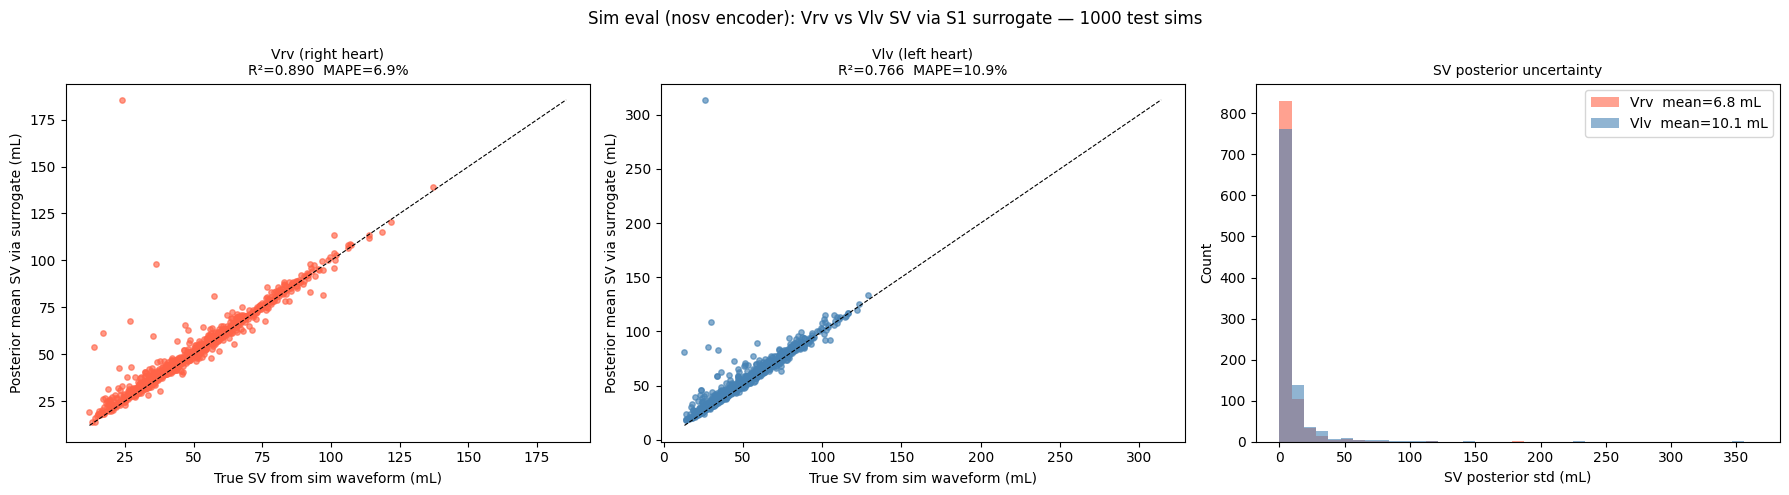

Vrv (right heart)          R²=0.890  MAPE=6.9%  post_std=6.8 mL
Vlv (left heart)           R²=0.766  MAPE=10.9%  post_std=6.8 mL


In [76]:
# Sim eval (nosv encoder): Vrv vs Vlv SV derivation — SV not in observation
# Drops SV scalar from x_test to get 808-dim input, runs enc_nosv + flow_nosv,
# then derives both RVSV (Vrv) and LVSV (Vlv) via S1 surrogate.
# Ground truth SV read directly from test HDF5 waveforms.

def metrics_xy(true, pred):
    r2   = pearsonr(true, pred)[0] ** 2
    mape = np.mean(np.abs(pred - true) / (np.abs(true) + 1e-9)) * 100
    return r2, mape

# Build 808-dim observations: drop SV scalar at position 807
# Layout: [wave(804), map(1), sbp(1), dbp(1), sv(1), hr(1)] -> drop index 807
x_test_nosv = torch.cat([x_test[:, :807], x_test[:, 808:]], dim=1)  # (N_SIM_EVAL, 808)
print(f'nosv obs dim: {x_test_nosv.shape[1]}')

# Run inference with nosv encoder + flow
print(f'Running inference on {N_SIM_EVAL} test sims (nosv encoder)...')
sim_samples_nosv = []
t0 = time.time()
with torch.no_grad():
    for i in range(0, len(x_test_nosv), 64):
        x_b = x_test_nosv[i:i+64].to(device)
        z_b = enc_nosv(x_b)
        for j in range(len(x_b)):
            s = flow_nosv.sample(
                (N_POSTERIOR_SAMPLES,), condition=z_b[j:j+1]
            ).squeeze(1).cpu()
            sim_samples_nosv.append(s)
        if (i // 64) % 5 == 0:
            print(f'  {i+len(x_b)}/{N_SIM_EVAL}  ({time.time()-t0:.0f}s)', end='\r', flush=True)
sim_samples_nosv = torch.stack(sim_samples_nosv)  # (N_SIM_EVAL, N_POSTERIOR_SAMPLES, 24)
print(f'\nDone. samples: {tuple(sim_samples_nosv.shape)}')

# Recover HR from x_test for surrogate reconstruction
_hr_p_mean = stats['parameters']['HR']['mean']
_hr_p_std  = stats['parameters']['HR']['std']
hr_sim = x_test[:, -1].numpy() * _hr_p_std + _hr_p_mean  # (N_SIM_EVAL,)

print('Deriving RVSV via Vrv...')
rvsv_sim = derive_sv(sim_samples_nosv.numpy(), hr_sim, vrv_idx, vrv_std)
print('Deriving LVSV via Vlv...')
lvsv_sim = derive_sv(sim_samples_nosv.numpy(), hr_sim, vlv_idx, vlv_std)

# Load ground-truth SV from test HDF5
test_entries = manifest_test['index'][:N_SIM_EVAL]
data_dir_test = SIM_ROOT / 'test'

vrv_gt_sim, vlv_gt_sim = [], []
for entry in test_entries:
    with h5py.File(data_dir_test / entry['file'], 'r') as _f:
        g = _f[entry['group']]
        vrv_gt_sim.append(float(g['waves/Vrv'][:].max() - g['waves/Vrv'][:].min()))
        vlv_gt_sim.append(float(g['waves/Vlv'][:].max() - g['waves/Vlv'][:].min()))
vrv_gt_sim = np.array(vrv_gt_sim)
vlv_gt_sim = np.array(vlv_gt_sim)

rvsv_sim_mean = rvsv_sim.mean(axis=1)
lvsv_sim_mean = lvsv_sim.mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label, sv_pred, sv_true, color in [
    (axes[0], 'Vrv (right heart)', rvsv_sim_mean, vrv_gt_sim, 'tomato'),
    (axes[1], 'Vlv (left heart)',  lvsv_sim_mean, vlv_gt_sim, 'steelblue'),
]:
    r2, mape = metrics_xy(sv_true, sv_pred)
    lo, hi = min(sv_true.min(), sv_pred.min()), max(sv_true.max(), sv_pred.max())
    ax.scatter(sv_true, sv_pred, s=15, alpha=0.65, color=color)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    ax.set_xlabel('True SV from sim waveform (mL)')
    ax.set_ylabel('Posterior mean SV via surrogate (mL)')
    ax.set_title(f'{label}\nR²={r2:.3f}  MAPE={mape:.1f}%', fontsize=10)

ax = axes[2]
std_vrv = rvsv_sim.std(axis=1)
std_vlv = lvsv_sim.std(axis=1)
bins = np.linspace(0, max(std_vrv.max(), std_vlv.max()) * 1.05, 40)
ax.hist(std_vrv, bins=bins, color='tomato',    alpha=0.6, label=f'Vrv  mean={std_vrv.mean():.1f} mL')
ax.hist(std_vlv, bins=bins, color='steelblue', alpha=0.6, label=f'Vlv  mean={std_vlv.mean():.1f} mL')
ax.set_xlabel('SV posterior std (mL)'); ax.set_ylabel('Count')
ax.set_title('SV posterior uncertainty', fontsize=10); ax.legend()

fig.suptitle(f'Sim eval (nosv encoder): Vrv vs Vlv SV via S1 surrogate — {N_SIM_EVAL} test sims', fontsize=12)
plt.tight_layout(); plt.show()

for label, sv_pred, sv_true in [
    ('Vrv (right heart)', rvsv_sim_mean, vrv_gt_sim),
    ('Vlv (left heart)',  lvsv_sim_mean, vlv_gt_sim),
]:
    r2, mape = metrics_xy(sv_true, sv_pred)
    print(f'{label:<25}  R²={r2:.3f}  MAPE={mape:.1f}%  post_std={rvsv_sim.std(axis=1).mean():.1f} mL')


Encoding test sims...
z_sims: (1000, 128)
Running 1NN proxy inference...
  done (66s)66s)
Deriving RVSV via Vrv (1NN)...
Deriving LVSV via Vlv (1NN)...


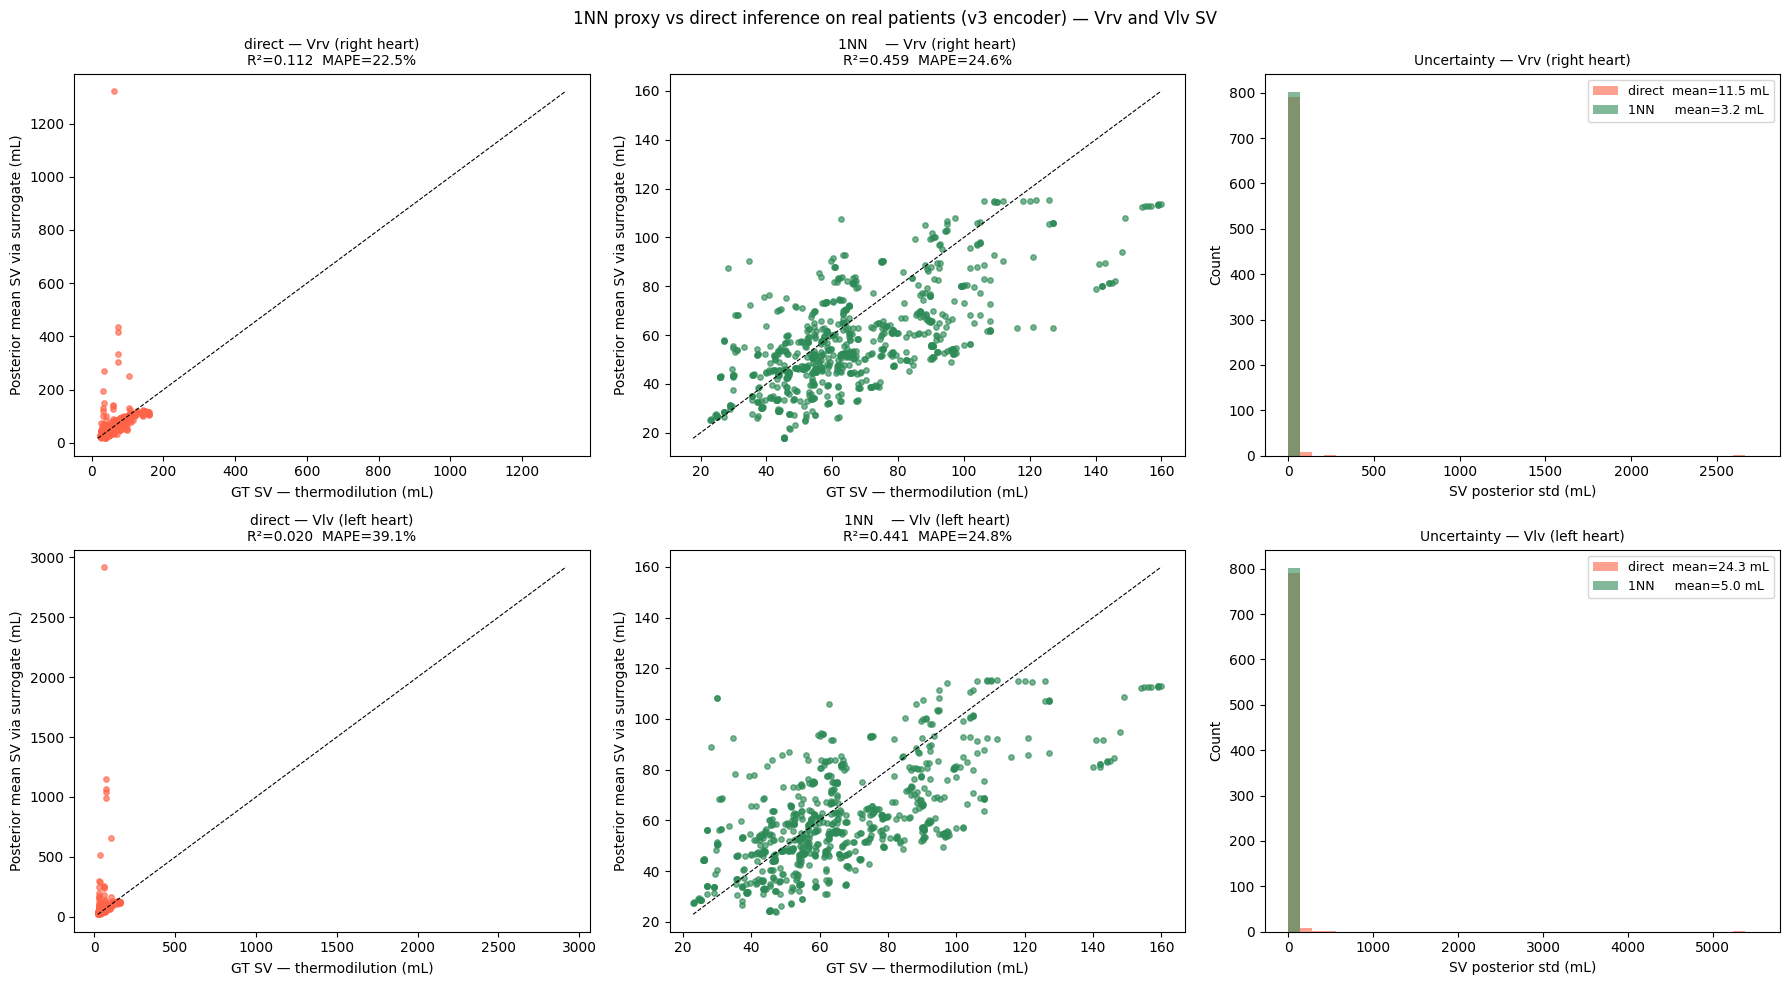

                     R²     MAPE    post_std
direct Vrv        0.112    22.5%      11.5 mL
1NN    Vrv        0.459    24.6%       3.2 mL
direct Vlv        0.020    39.1%      24.3 mL
1NN    Vlv        0.441    24.8%       5.0 mL


In [77]:
# 1NN proxy inference for real patients: find nearest sim in latent space,
# use that sim's z to condition the flow instead of encoder(x_real).
# Diagnostic: if SV improves, posterior samples from direct real inference are
# drifting outside the sim theta prior; if not, the observation is the bottleneck.

# Encode all test sims
print('Encoding test sims...')
with torch.no_grad():
    z_sims_parts = []
    for i in range(0, len(x_test), 256):
        z_sims_parts.append(encoder(x_test[i:i+256].to(device)))
    z_sims = torch.cat(z_sims_parts, dim=0).cpu()  # (N_SIM_EVAL, latent_dim)
print(f'z_sims: {tuple(z_sims.shape)}')

# For each real patient find nearest sim by L2, sample from that z
print('Running 1NN proxy inference...')
samp_1nn = []
t0 = time.time()
for pi, pat in enumerate(patients):
    with torch.no_grad():
        z_real = encoder(pat['x_avg'].unsqueeze(0).to(device)).cpu()  # (1, D)
        i_nn   = ((z_sims - z_real) ** 2).sum(dim=1).argmin().item()
        z_nn   = z_sims[i_nn:i_nn+1].to(device)
        s = flow_net.sample((N_ABL,), condition=z_nn).squeeze(1).cpu()
    samp_1nn.append(s.numpy())
    if pi % 100 == 0:
        print(f'  {pi}/{len(patients)}  ({time.time()-t0:.0f}s)', end='\r', flush=True)
samp_1nn = np.stack(samp_1nn)  # (N_pat, N_ABL, 24)
print(f'  done ({time.time()-t0:.0f}s)')

# Derive RVSV and LVSV via surrogate
print('Deriving RVSV via Vrv (1NN)...')
rvsv_1nn = derive_sv(samp_1nn, hr_arr, vrv_idx, vrv_std)
print('Deriving LVSV via Vlv (1NN)...')
lvsv_1nn = derive_sv(samp_1nn, hr_arr, vlv_idx, vlv_std)

# Plot: direct vs 1NN, for Vrv (row 0) and Vlv (row 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (sv_direct, sv_1nn, wave_label) in enumerate([
    (rvsv_v3, rvsv_1nn, 'Vrv (right heart)'),
    (lvsv_v3, lvsv_1nn, 'Vlv (left heart)'),
]):
    for col, (sv_arr, label, color) in enumerate([
        (sv_direct, f'direct — {wave_label}', 'tomato'),
        (sv_1nn,    f'1NN    — {wave_label}', 'seagreen'),
    ]):
        sv_mean = sv_arr.mean(axis=1)
        r2, mape = metrics_xy(sv_gt, sv_mean)
        ax = axes[row, col]
        lo = min(sv_gt.min(), sv_mean.min()); hi = max(sv_gt.max(), sv_mean.max())
        ax.scatter(sv_gt, sv_mean, s=15, alpha=0.65, color=color)
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
        ax.set_xlabel('GT SV — thermodilution (mL)')
        ax.set_ylabel('Posterior mean SV via surrogate (mL)')
        ax.set_title(f'{label}\nR²={r2:.3f}  MAPE={mape:.1f}%', fontsize=10)

    ax = axes[row, 2]
    std_d = sv_direct.std(axis=1); std_n = sv_1nn.std(axis=1)
    bins  = np.linspace(0, max(std_d.max(), std_n.max()) * 1.05, 40)
    ax.hist(std_d, bins=bins, color='tomato',   alpha=0.6, label=f'direct  mean={std_d.mean():.1f} mL')
    ax.hist(std_n, bins=bins, color='seagreen', alpha=0.6, label=f'1NN     mean={std_n.mean():.1f} mL')
    ax.set_xlabel('SV posterior std (mL)'); ax.set_ylabel('Count')
    ax.set_title(f'Uncertainty — {wave_label}', fontsize=10); ax.legend(fontsize=9)

fig.suptitle('1NN proxy vs direct inference on real patients (v3 encoder) — Vrv and Vlv SV',
             fontsize=12)
plt.tight_layout(); plt.show()

print(f'{"":15}  {"R²":>6}  {"MAPE":>7}  {"post_std":>10}')
for label, sv_arr in [
    ('direct Vrv', rvsv_v3),
    ('1NN    Vrv', rvsv_1nn),
    ('direct Vlv', lvsv_v3),
    ('1NN    Vlv', lvsv_1nn),
]:
    sv_mean = sv_arr.mean(axis=1)
    r2, mape = metrics_xy(sv_gt, sv_mean)
    print(f'{label:<15}  {r2:>6.3f}  {mape:>6.1f}%  {sv_arr.std(axis=1).mean():>8.1f} mL')


Encoding test sims (nosv)...
z_sims_nosv: (1000, 128)
Running 1NN proxy inference (nosv)...
  done (66s)66s)
Deriving RVSV via Vrv (1NN nosv)...
Deriving LVSV via Vlv (1NN nosv)...


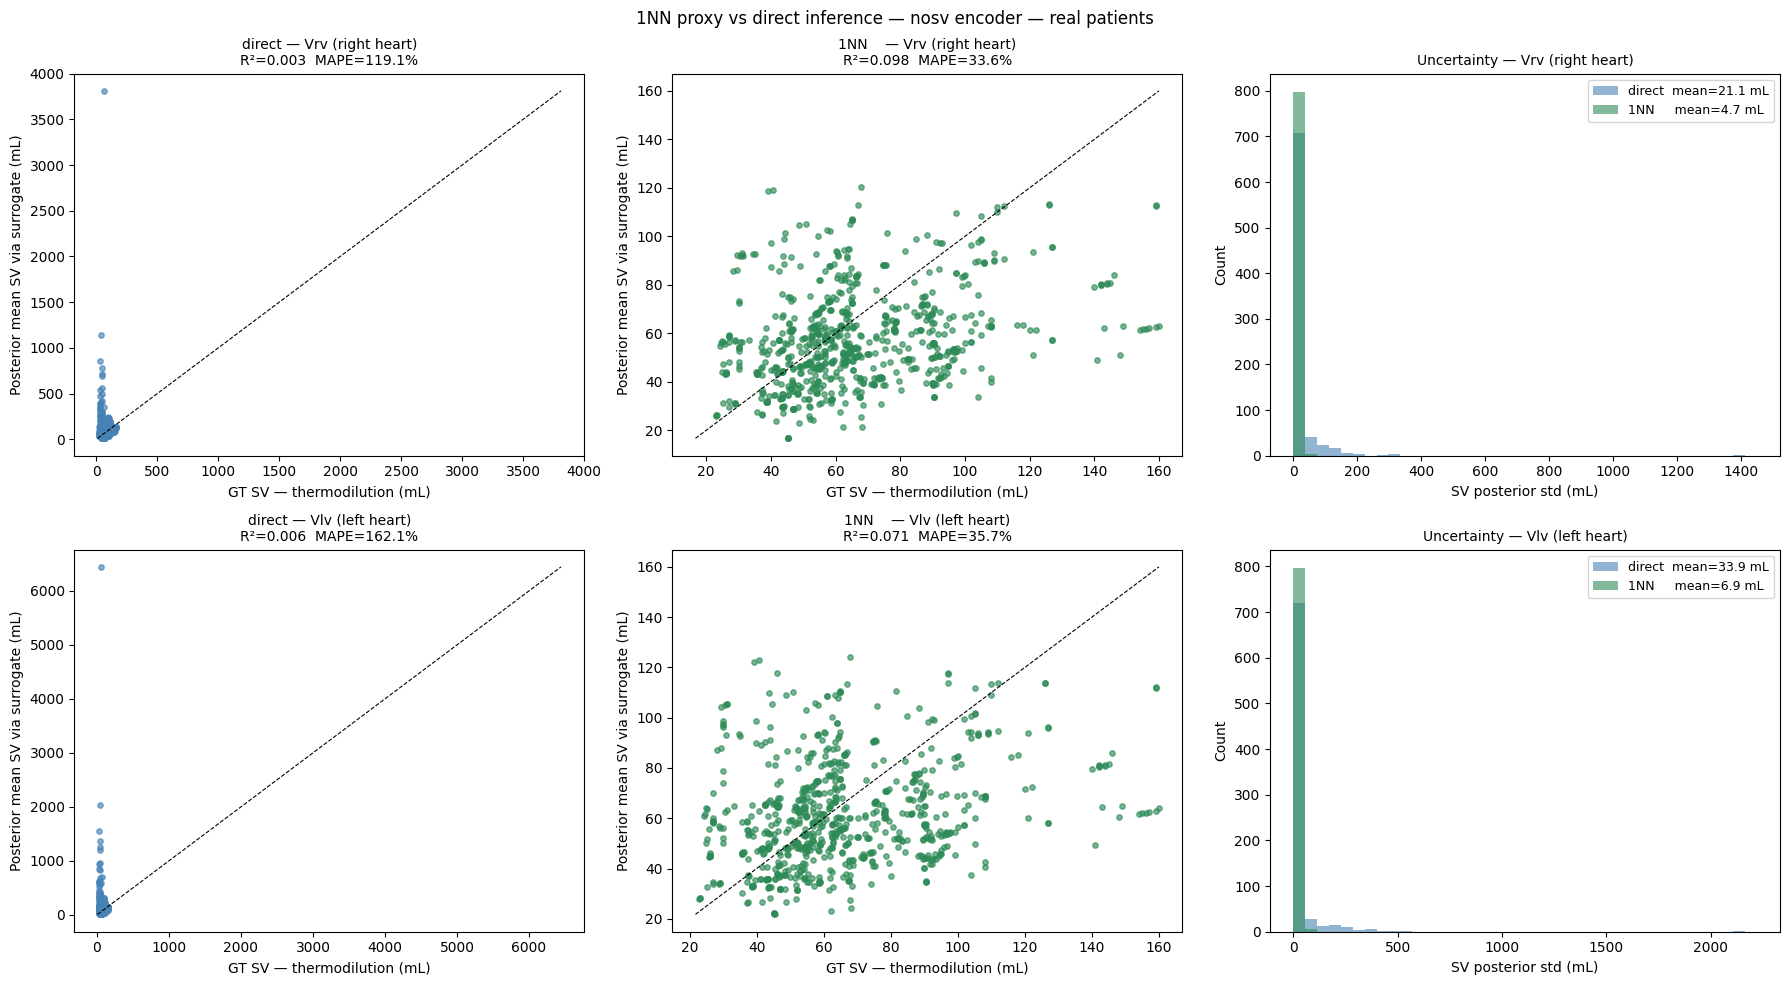

                     R²     MAPE    post_std
direct Vrv        0.003   119.1%      21.1 mL
1NN    Vrv        0.098    33.6%       4.7 mL
direct Vlv        0.006   162.1%      33.9 mL
1NN    Vlv        0.071    35.7%       6.9 mL


In [78]:
# 1NN proxy inference — nosv encoder (808-dim obs, no SV scalar)
# Same diagnostic as above but for enc_nosv + flow_nosv.

print('Encoding test sims (nosv)...')
with torch.no_grad():
    z_sims_nosv_parts = []
    for i in range(0, len(x_test_nosv), 256):
        z_sims_nosv_parts.append(enc_nosv(x_test_nosv[i:i+256].to(device)))
    z_sims_nosv = torch.cat(z_sims_nosv_parts, dim=0).cpu()
print(f'z_sims_nosv: {tuple(z_sims_nosv.shape)}')

print('Running 1NN proxy inference (nosv)...')
samp_1nn_nosv = []
t0 = time.time()
for pi, pat in enumerate(patients):
    with torch.no_grad():
        z_real = enc_nosv(pat['x_avg_nosv'].unsqueeze(0).to(device)).cpu()
        i_nn   = ((z_sims_nosv - z_real) ** 2).sum(dim=1).argmin().item()
        z_nn   = z_sims_nosv[i_nn:i_nn+1].to(device)
        s = flow_nosv.sample((N_ABL,), condition=z_nn).squeeze(1).cpu()
    samp_1nn_nosv.append(s.numpy())
    if pi % 100 == 0:
        print(f'  {pi}/{len(patients)}  ({time.time()-t0:.0f}s)', end='\r', flush=True)
samp_1nn_nosv = np.stack(samp_1nn_nosv)
print(f'  done ({time.time()-t0:.0f}s)')

print('Deriving RVSV via Vrv (1NN nosv)...')
rvsv_1nn_nosv = derive_sv(samp_1nn_nosv, hr_arr, vrv_idx, vrv_std)
print('Deriving LVSV via Vlv (1NN nosv)...')
lvsv_1nn_nosv = derive_sv(samp_1nn_nosv, hr_arr, vlv_idx, vlv_std)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (sv_direct, sv_1nn, wave_label) in enumerate([
    (rvsv_v3_nosv, rvsv_1nn_nosv, 'Vrv (right heart)'),
    (lvsv_v3_nosv, lvsv_1nn_nosv, 'Vlv (left heart)'),
]):
    for col, (sv_arr, label, color) in enumerate([
        (sv_direct, f'direct — {wave_label}', 'steelblue'),
        (sv_1nn,    f'1NN    — {wave_label}', 'seagreen'),
    ]):
        sv_mean = sv_arr.mean(axis=1)
        r2, mape = metrics_xy(sv_gt, sv_mean)
        ax = axes[row, col]
        lo = min(sv_gt.min(), sv_mean.min()); hi = max(sv_gt.max(), sv_mean.max())
        ax.scatter(sv_gt, sv_mean, s=15, alpha=0.65, color=color)
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
        ax.set_xlabel('GT SV — thermodilution (mL)')
        ax.set_ylabel('Posterior mean SV via surrogate (mL)')
        ax.set_title(f'{label}\nR²={r2:.3f}  MAPE={mape:.1f}%', fontsize=10)

    ax = axes[row, 2]
    std_d = sv_direct.std(axis=1); std_n = sv_1nn.std(axis=1)
    bins  = np.linspace(0, max(std_d.max(), std_n.max()) * 1.05, 40)
    ax.hist(std_d, bins=bins, color='steelblue', alpha=0.6, label=f'direct  mean={std_d.mean():.1f} mL')
    ax.hist(std_n, bins=bins, color='seagreen',  alpha=0.6, label=f'1NN     mean={std_n.mean():.1f} mL')
    ax.set_xlabel('SV posterior std (mL)'); ax.set_ylabel('Count')
    ax.set_title(f'Uncertainty — {wave_label}', fontsize=10); ax.legend(fontsize=9)

fig.suptitle('1NN proxy vs direct inference — nosv encoder — real patients', fontsize=12)
plt.tight_layout(); plt.show()

print(f'{"":15}  {"R²":>6}  {"MAPE":>7}  {"post_std":>10}')
for label, sv_arr in [
    ('direct Vrv', rvsv_v3_nosv),
    ('1NN    Vrv', rvsv_1nn_nosv),
    ('direct Vlv', lvsv_v3_nosv),
    ('1NN    Vlv', lvsv_1nn_nosv),
]:
    sv_mean = sv_arr.mean(axis=1)
    r2, mape = metrics_xy(sv_gt, sv_mean)
    print(f'{label:<15}  {r2:>6.3f}  {mape:>6.1f}%  {sv_arr.std(axis=1).mean():>8.1f} mL')


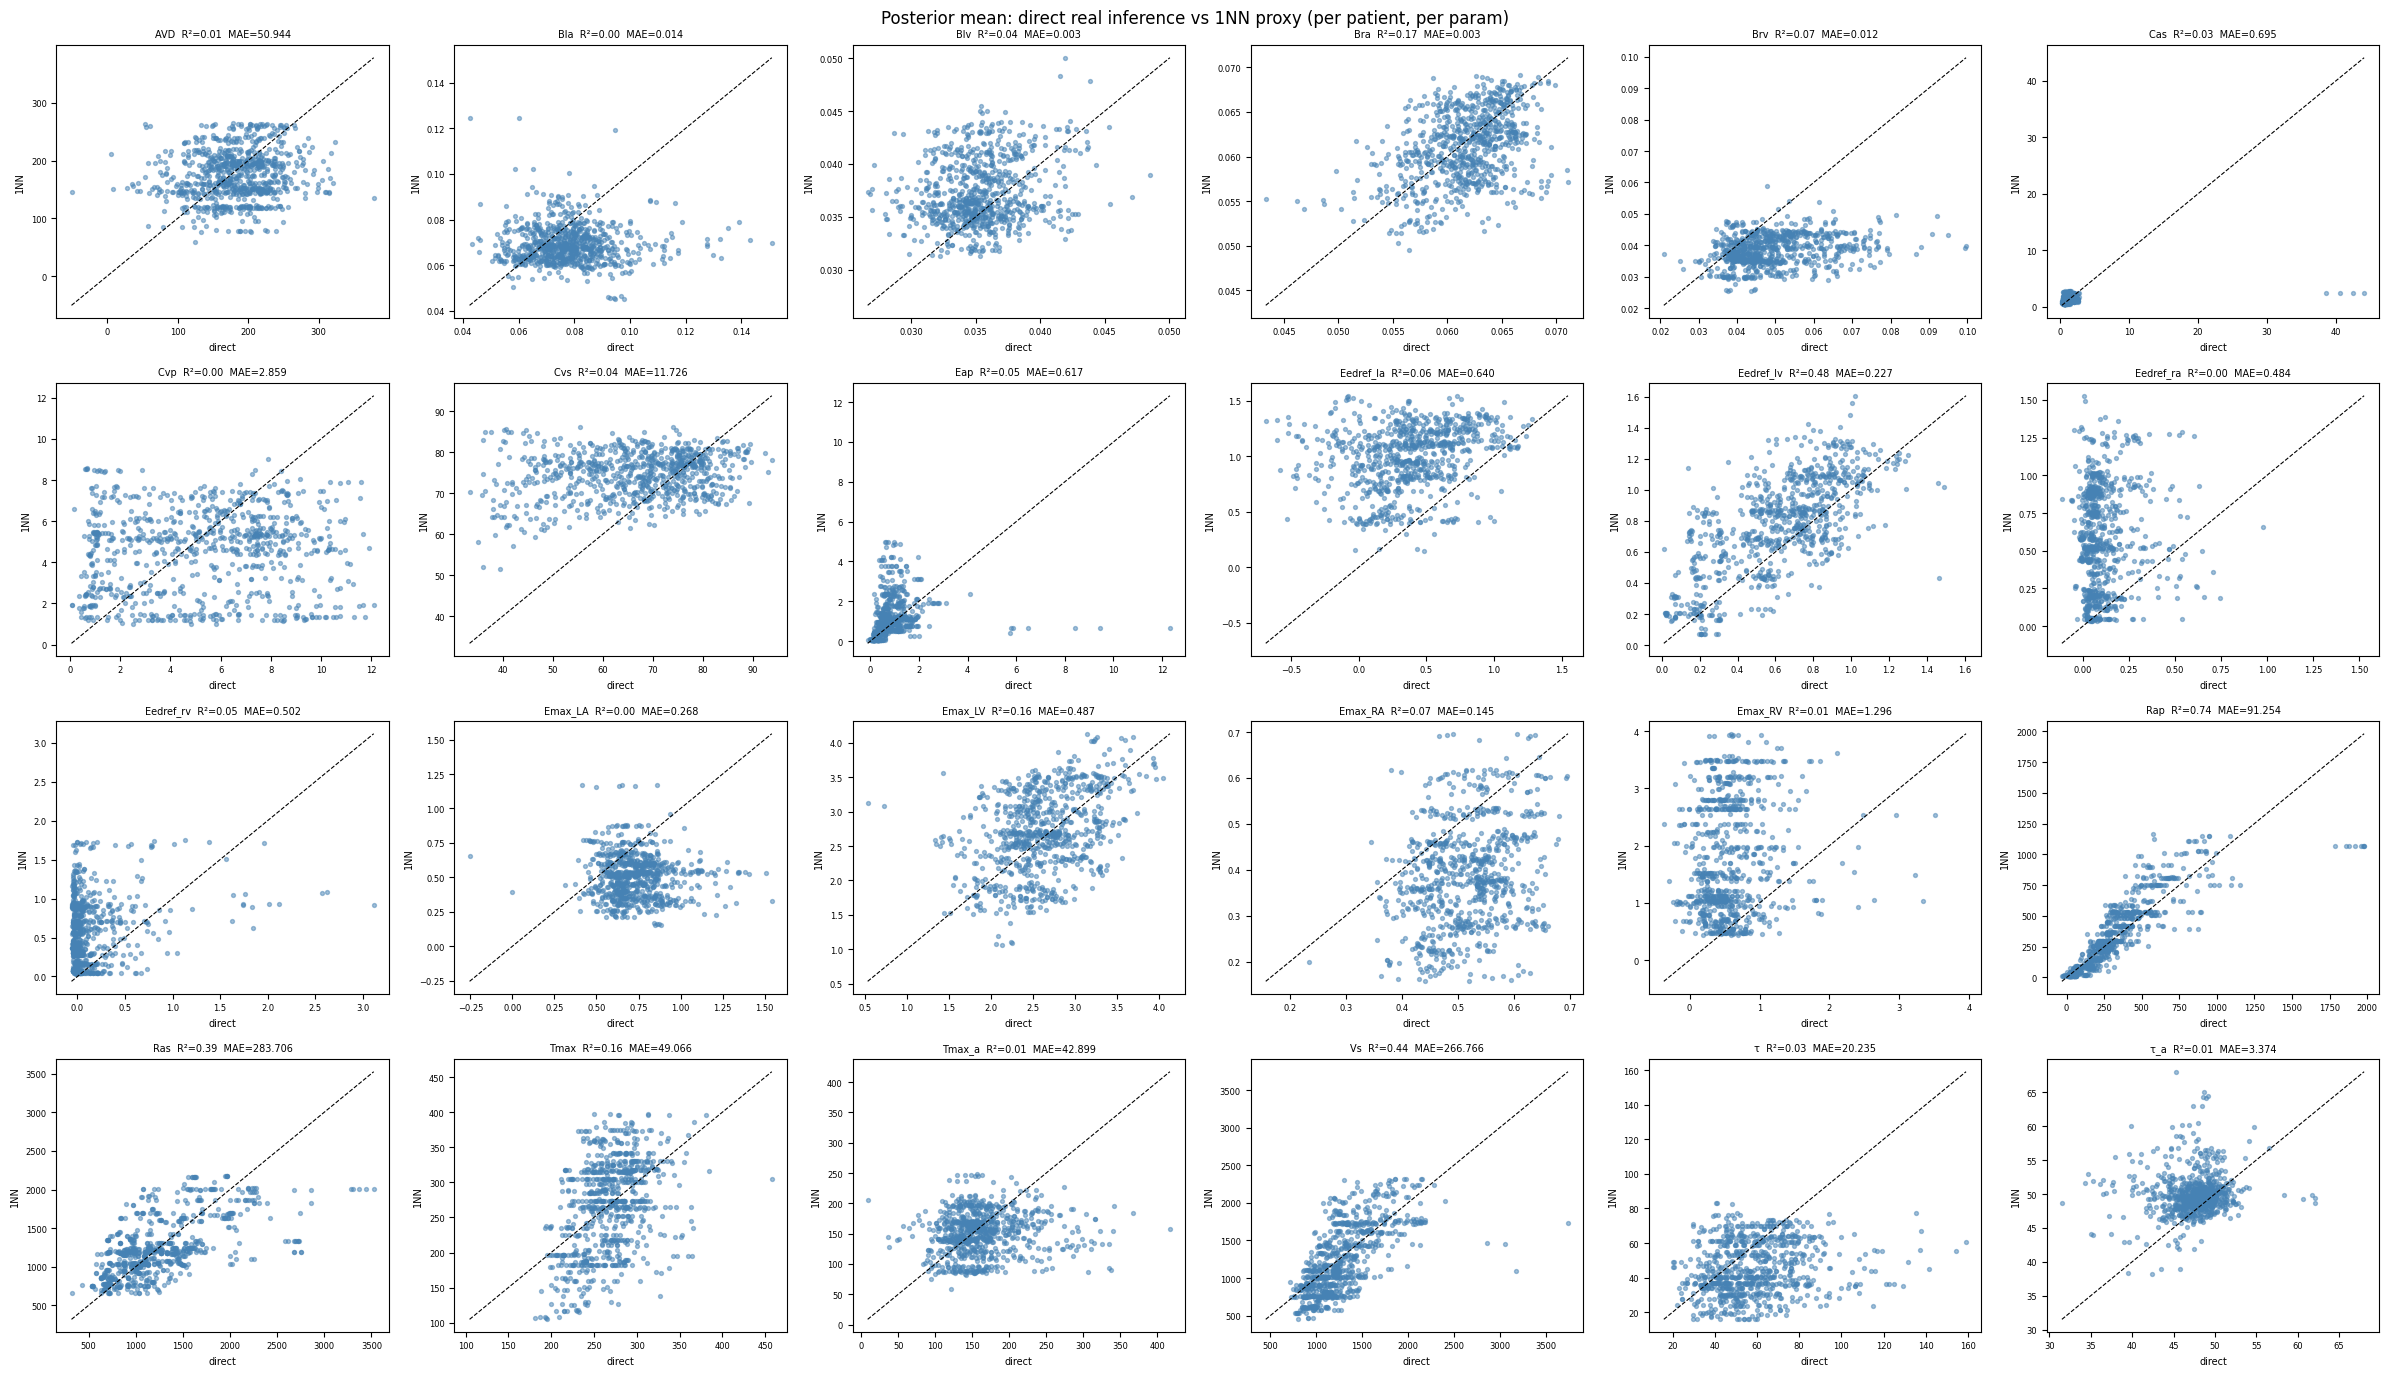

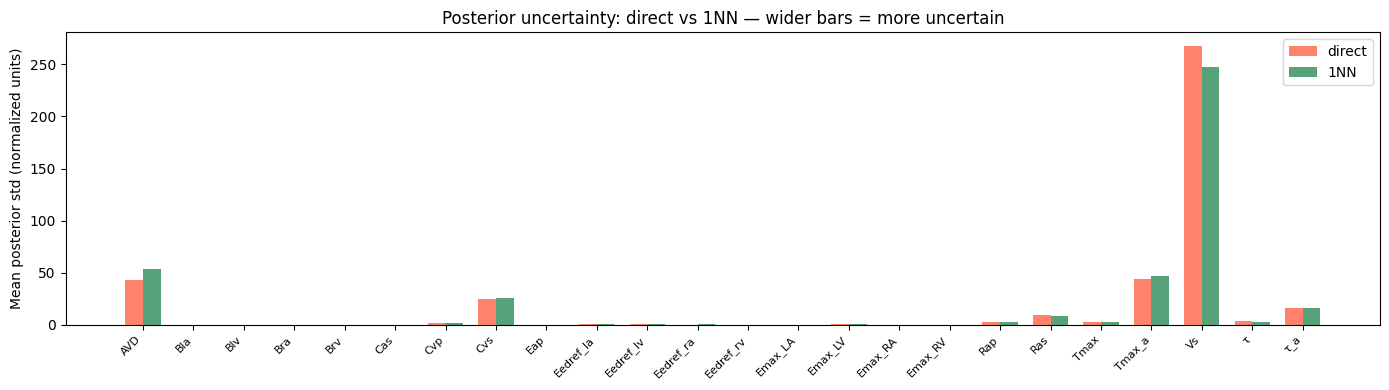

Mean |direct_mean - 1nn_mean| per param:
  overall: 34.5093  max: 283.7061 (Ras)

Param             MAD   std_direct    std_1nn
---------------------------------------------
AVD           50.9444      42.8797    53.4047
Bla            0.0140       0.0274     0.0254
Blv            0.0035       0.0103     0.0105
Bra            0.0034       0.0189     0.0198
Brv            0.0117       0.0143     0.0102
Cas            0.6947       0.0190     0.0156
Cvp            2.8587       1.5228     1.3450
Cvs           11.7262      24.6947    25.2834
Eap            0.6170       0.0210     0.0211
Eedref_la      0.6404       0.5842     0.6554
Eedref_lv      0.2271       0.4059     0.4894
Eedref_ra      0.4838       0.0784     0.3114
Eedref_rv      0.5023       0.0544     0.2384
Emax_LA        0.2679       0.2448     0.2242
Emax_LV        0.4865       0.9657     0.9824
Emax_RA        0.1450       0.1789     0.1676
Emax_RV        1.2964       0.0689     0.0983
Rap           91.2539       2.4128     2.694

In [79]:
# Compare posterior theta distributions: direct real inference vs 1NN proxy
# If means/stds look similar -> decoder amplifying small shift (brittleness)
# If qualitatively different -> flow producing OOD posteriors on real latents

means_direct = samp_v3.mean(axis=1)    # (N_pat, 24)
means_1nn    = samp_1nn.mean(axis=1)   # (N_pat, 24)
stds_direct  = samp_v3.std(axis=1)     # (N_pat, 24)
stds_1nn     = samp_1nn.std(axis=1)    # (N_pat, 24)

# Scatter: direct posterior mean vs 1NN posterior mean, one panel per param
ncols, nrows = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))

for i, name in enumerate(PARAM_KEYS_INFER):
    ax = axes[i // ncols, i % ncols]
    d, n = means_direct[:, i], means_1nn[:, i]
    lo, hi = min(d.min(), n.min()), max(d.max(), n.max())
    ax.scatter(d, n, s=8, alpha=0.5, color='steelblue', rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    r2 = pearsonr(d, n)[0] ** 2
    mae = np.mean(np.abs(d - n))
    ax.set_title(f'{name}  R²={r2:.2f}  MAE={mae:.3f}', fontsize=7)
    ax.set_xlabel('direct', fontsize=7); ax.set_ylabel('1NN', fontsize=7)
    ax.tick_params(labelsize=6)

for i in range(len(PARAM_KEYS_INFER), nrows * ncols):
    axes[i // ncols, i % ncols].axis('off')

fig.suptitle('Posterior mean: direct real inference vs 1NN proxy (per patient, per param)', fontsize=12)
plt.tight_layout(); plt.show()

# Posterior std comparison: direct vs 1NN, aggregated across patients
mean_std_direct = stds_direct.mean(axis=0)   # (24,)
mean_std_1nn    = stds_1nn.mean(axis=0)       # (24,)

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(PARAM_KEYS_INFER))
w = 0.35
ax.bar(x - w/2, mean_std_direct, width=w, color='tomato',   alpha=0.8, label='direct')
ax.bar(x + w/2, mean_std_1nn,    width=w, color='seagreen', alpha=0.8, label='1NN')
ax.set_xticks(x); ax.set_xticklabels(PARAM_KEYS_INFER, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean posterior std (normalized units)')
ax.set_title('Posterior uncertainty: direct vs 1NN — wider bars = more uncertain'); ax.legend()
plt.tight_layout(); plt.show()

# Summary: mean absolute difference in posterior means across all params and patients
mad_per_param = np.abs(means_direct - means_1nn).mean(axis=0)  # (24,)
print(f'Mean |direct_mean - 1nn_mean| per param:')
print(f'  overall: {mad_per_param.mean():.4f}  max: {mad_per_param.max():.4f} ({PARAM_KEYS_INFER[mad_per_param.argmax()]})')
print()
print(f'{"Param":<12} {"MAD":>8} {"std_direct":>12} {"std_1nn":>10}')
print('-' * 45)
for i, name in enumerate(PARAM_KEYS_INFER):
    print(f'{name:<12} {mad_per_param[i]:>8.4f} {mean_std_direct[i]:>12.4f} {mean_std_1nn[i]:>10.4f}')
